In [1]:
import mlflow
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from collections import defaultdict

import sys
sys.path.insert(0, "../../run")
from const import REPO_PATH
from experiment_config import TRAINGING_CONFIG

sys.path.insert(1, f"{REPO_PATH}")
from src.model.experiment_utils import *
from src.model.model_utils import *
from src.model.models import LSTMClassifier, TCNClassifier
from src.model.experiment_utils import run_multiclass_distribution_experiment_seq

In [2]:
sequence_length=5

In [3]:
features_path = f"{TRAINGING_CONFIG['features_path']}/all_combined_features_2017-24.csv"
output_dir = f"{REPO_PATH}/models/ml_models"

In [4]:
seasons=sorted(TRAINGING_CONFIG['seasons'])
target_dfs=[pd.read_csv(f"{TRAINGING_CONFIG['processed_data_path']}/{season}/all_target_df.csv") for season in seasons[1:]]
for df in target_dfs:
    df['date']= pd.to_datetime(df['date'])
target_df = pd.concat(target_dfs, ignore_index=True)
target_columns= list(TRAINGING_CONFIG['target_ranges'].keys())

In [5]:
feature_df = pd.read_csv(features_path)
feature_df['date']= pd.to_datetime(feature_df['date'])
feature_df, target_df=align_on_keys(feature_df, target_df, TRAINGING_CONFIG['key_columns'])

In [6]:
param_grid = {
    'model_params.hidden_dim': [64],
    'model_params.num_layers': [4, 3],
    'learning_rate': [0.00001, 0.00005],
    'batch_size': [64],
    'epochs': [5000]
}

In [7]:
from sklearn.preprocessing import StandardScaler

# Select only numeric columns for standardization
numeric_cols = feature_df.select_dtypes(include=[np.number]).columns

scaler = StandardScaler()
feature_df[numeric_cols] = scaler.fit_transform(feature_df[numeric_cols])

In [8]:
feature_df.fillna(0, inplace=True)

Preparing sequence data for target: home_goals
  X_seq shape: (2280, 5, 2726), y_seq shape: (2280,)
Training LSTMClassifier on home_goals with param grid: {'model_params.hidden_dim': [64], 'model_params.num_layers': [4, 3], 'learning_rate': [1e-05, 5e-05], 'batch_size': [64], 'epochs': [5000]}
Using range-based class conversion with range: (0, 5)
Training fold 1/5 with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 4, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 1.9461, LR: 0.000000
Epoch 500/5000, Loss: 1.2999, LR: 0.000010
Epoch 1000/5000, Loss: 0.6414, LR: 0.000010
Epoch 1500/5000, Loss: 0.5381, LR: 0.000010
Epoch 2000/5000, Loss: 0.4892, LR: 0.000010
Epoch 2500/5000, Loss: 0.4582, LR: 0.000010
Epoch 3000/5000, Loss: 0.4722, LR: 0.000010
Epoch 3500/5000, Loss: 0.4950, LR: 0.000010
Epoch 4000/5000, Loss: 0.4725, LR: 0.000010
Epoch 4500/5000, Loss: 0.4655, LR: 0.000010
Epoch 5000/5000, Loss: 0.4565, LR: 0.000010


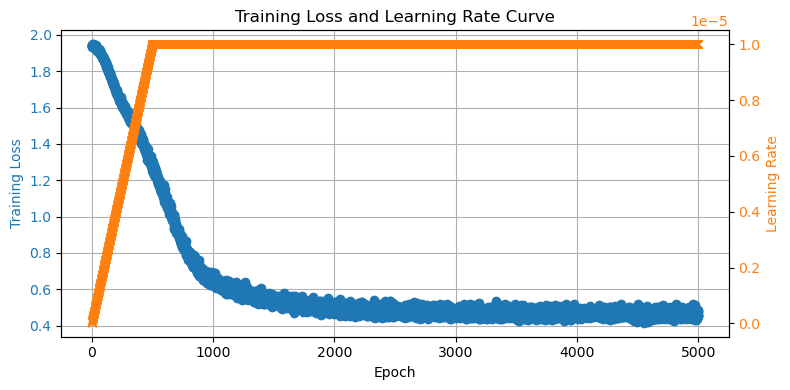

Training fold 2/5 with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 4, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.1000, LR: 0.000000
Epoch 500/5000, Loss: 1.0709, LR: 0.000010
Epoch 1000/5000, Loss: 0.5563, LR: 0.000010
Epoch 1500/5000, Loss: 0.4719, LR: 0.000010
Epoch 2000/5000, Loss: 0.4619, LR: 0.000010
Epoch 2500/5000, Loss: 0.4622, LR: 0.000010
Epoch 3000/5000, Loss: 0.4505, LR: 0.000010
Epoch 3500/5000, Loss: 0.4490, LR: 0.000010
Epoch 4000/5000, Loss: 0.4569, LR: 0.000010
Epoch 4500/5000, Loss: 0.4526, LR: 0.000010
Epoch 5000/5000, Loss: 0.4578, LR: 0.000010


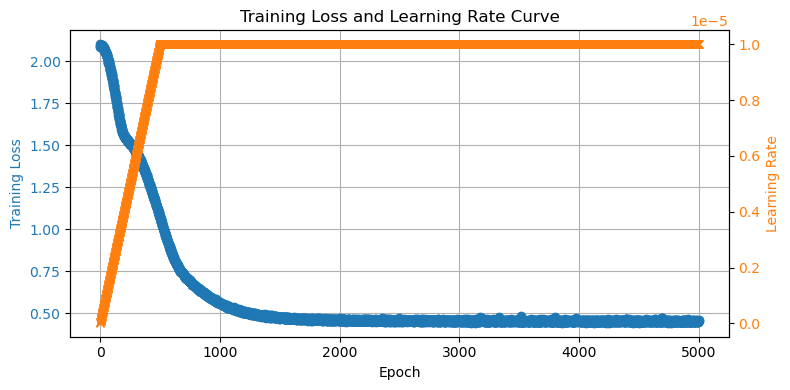

Training fold 3/5 with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 4, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 1.7479, LR: 0.000000
Epoch 500/5000, Loss: 0.9233, LR: 0.000010
Epoch 1000/5000, Loss: 0.4935, LR: 0.000010
Epoch 1500/5000, Loss: 0.4752, LR: 0.000010
Epoch 2000/5000, Loss: 0.4651, LR: 0.000010
Epoch 2500/5000, Loss: 0.4829, LR: 0.000010
Epoch 3000/5000, Loss: 0.4304, LR: 0.000010
Epoch 3500/5000, Loss: 0.4303, LR: 0.000010
Epoch 4000/5000, Loss: 0.4282, LR: 0.000010
Epoch 4500/5000, Loss: 0.4313, LR: 0.000010
Epoch 5000/5000, Loss: 0.4851, LR: 0.000010


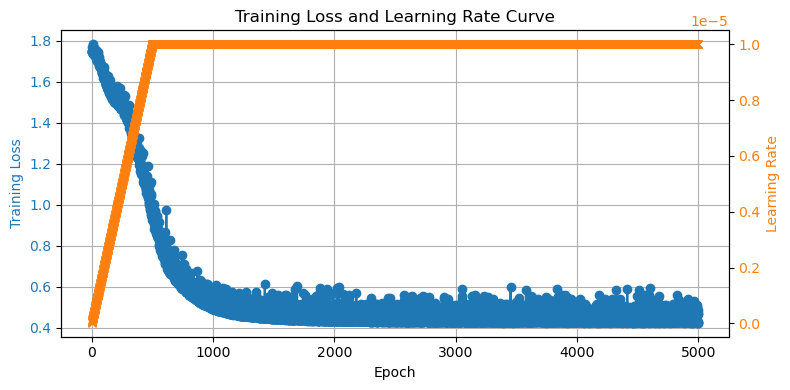

Training fold 4/5 with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 4, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 1.8341, LR: 0.000000
Epoch 500/5000, Loss: 0.9349, LR: 0.000010
Epoch 1000/5000, Loss: 0.5174, LR: 0.000010
Epoch 1500/5000, Loss: 0.4873, LR: 0.000010
Epoch 2000/5000, Loss: 0.4870, LR: 0.000010
Epoch 2500/5000, Loss: 0.4841, LR: 0.000010
Epoch 3000/5000, Loss: 0.4825, LR: 0.000010
Epoch 3500/5000, Loss: 0.4859, LR: 0.000010
Epoch 4000/5000, Loss: 0.4793, LR: 0.000010
Epoch 4500/5000, Loss: 0.4843, LR: 0.000010
Epoch 5000/5000, Loss: 0.4885, LR: 0.000010


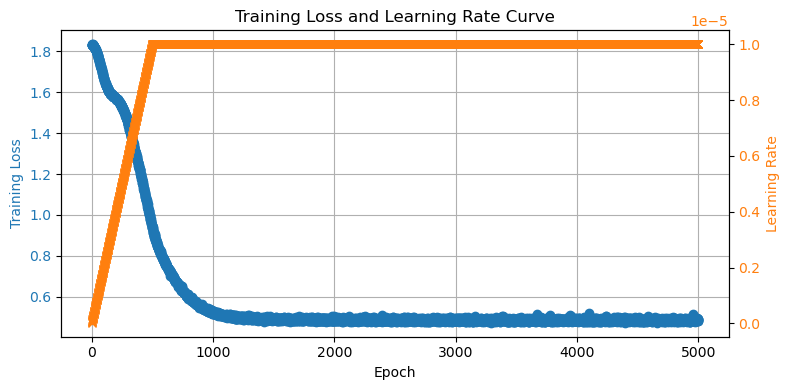

Training fold 5/5 with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 4, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.0710, LR: 0.000000
Epoch 500/5000, Loss: 0.9006, LR: 0.000010
Epoch 1000/5000, Loss: 0.5128, LR: 0.000010
Epoch 1500/5000, Loss: 0.5014, LR: 0.000010
Epoch 2000/5000, Loss: 0.4959, LR: 0.000010
Epoch 2500/5000, Loss: 0.4917, LR: 0.000010
Epoch 3000/5000, Loss: 0.4917, LR: 0.000010
Epoch 3500/5000, Loss: 0.4949, LR: 0.000010
Epoch 4000/5000, Loss: 0.4911, LR: 0.000010
Epoch 4500/5000, Loss: 0.4951, LR: 0.000010
Epoch 5000/5000, Loss: 0.4901, LR: 0.000010


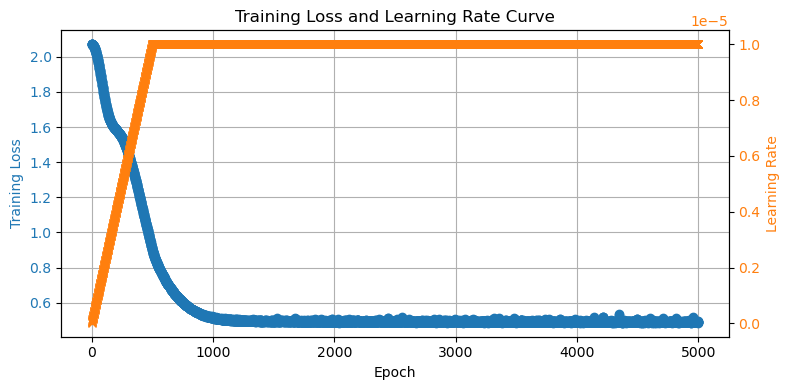

Epoch 1/5000, Loss: 1.9987, LR: 0.000000
Epoch 500/5000, Loss: 0.9079, LR: 0.000010
Epoch 1000/5000, Loss: 0.5416, LR: 0.000010
Epoch 1500/5000, Loss: 0.5137, LR: 0.000010
Epoch 2000/5000, Loss: 0.4893, LR: 0.000010
Epoch 2500/5000, Loss: 0.5143, LR: 0.000010
Epoch 3000/5000, Loss: 0.5033, LR: 0.000010
Epoch 3500/5000, Loss: 0.4931, LR: 0.000010
Epoch 4000/5000, Loss: 0.5198, LR: 0.000010
Epoch 4500/5000, Loss: 0.5074, LR: 0.000010
Epoch 5000/5000, Loss: 0.5326, LR: 0.000010


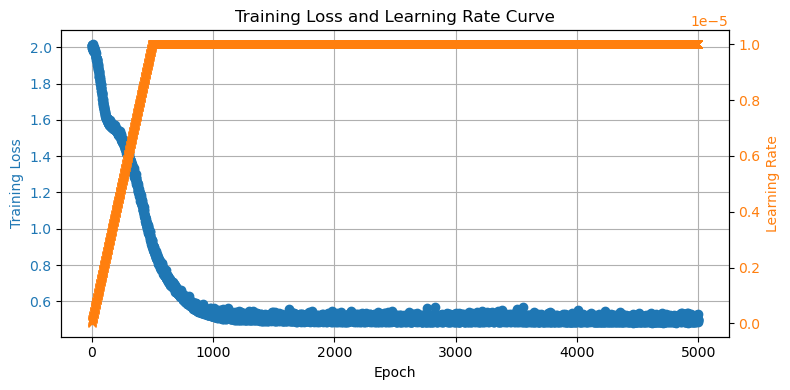

{'home_goals_train_accuracy': 0.7998440545808967, 'home_goals_train_precision': 0.9447179458412203, 'home_goals_valid_accuracy': 0.30935672514619883, 'home_goals_valid_precision': 0.17520511385017792, 'home_goals_test_accuracy': 0.25877192982456143, 'home_goals_test_precision': 0.13659147869674185, 'home_goals_train_lte_0_accuracy': 0.9341520467836256, 'home_goals_train_lte_0_accuracy_std': 0.007736999021539761, 'home_goals_train_lte_0_precision': 1.0, 'home_goals_train_lte_0_precision_std': 0.0, 'home_goals_train_gt_0_accuracy': 0.9341520467836256, 'home_goals_train_gt_0_accuracy_std': 0.007736999021539761, 'home_goals_train_gt_0_precision': 0.9198593658407702, 'home_goals_train_gt_0_precision_std': 0.010755488823689506, 'home_goals_train_gt_1_accuracy': 0.8656920077972708, 'home_goals_train_gt_1_accuracy_std': 0.012377016415897968, 'home_goals_train_gt_1_precision': 1.0, 'home_goals_train_gt_1_precision_std': 0.0, 'home_goals_train_gt_2_accuracy': 0.9450584795321637, 'home_goals_trai

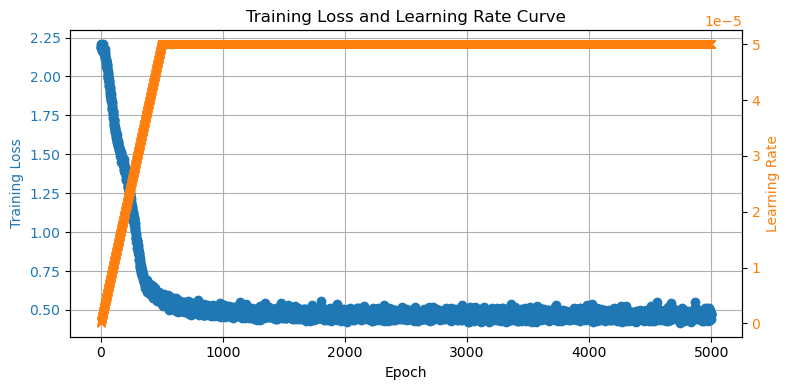

Training fold 2/precision with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 4, 'learning_rate': 5e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.6697, LR: 0.000000
Epoch 500/5000, Loss: 0.5069, LR: 0.000050
Epoch 1000/5000, Loss: 0.4581, LR: 0.000050
Epoch 1500/5000, Loss: 0.4482, LR: 0.000050
Epoch 2000/5000, Loss: 0.4456, LR: 0.000050
Epoch 2500/5000, Loss: 0.4478, LR: 0.000050
Epoch 3000/5000, Loss: 0.4469, LR: 0.000050
Epoch 3500/5000, Loss: 0.4469, LR: 0.000050
Epoch 4000/5000, Loss: 0.4473, LR: 0.000050
Epoch 4500/5000, Loss: 0.4442, LR: 0.000050
Epoch 5000/5000, Loss: 0.4499, LR: 0.000050


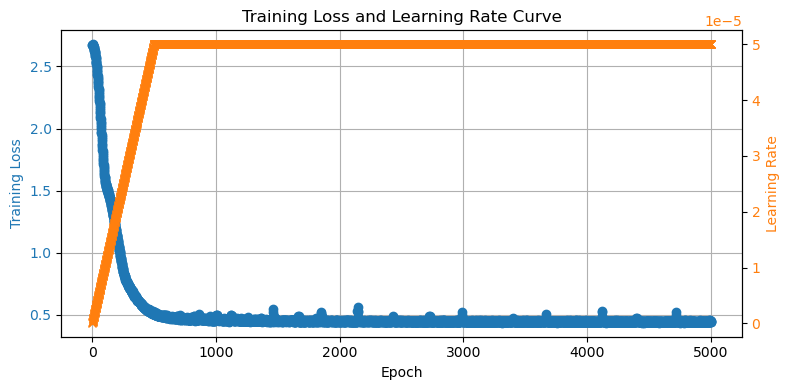

Training fold 3/precision with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 4, 'learning_rate': 5e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.0814, LR: 0.000000
Epoch 500/5000, Loss: 0.4858, LR: 0.000050
Epoch 1000/5000, Loss: 0.4460, LR: 0.000050
Epoch 1500/5000, Loss: 0.4659, LR: 0.000050
Epoch 2000/5000, Loss: 0.4236, LR: 0.000050
Epoch 2500/5000, Loss: 0.4236, LR: 0.000050
Epoch 3000/5000, Loss: 0.4539, LR: 0.000050
Epoch 3500/5000, Loss: 0.4318, LR: 0.000050
Epoch 4000/5000, Loss: 0.4209, LR: 0.000050
Epoch 4500/5000, Loss: 0.4861, LR: 0.000050
Epoch 5000/5000, Loss: 0.4487, LR: 0.000050


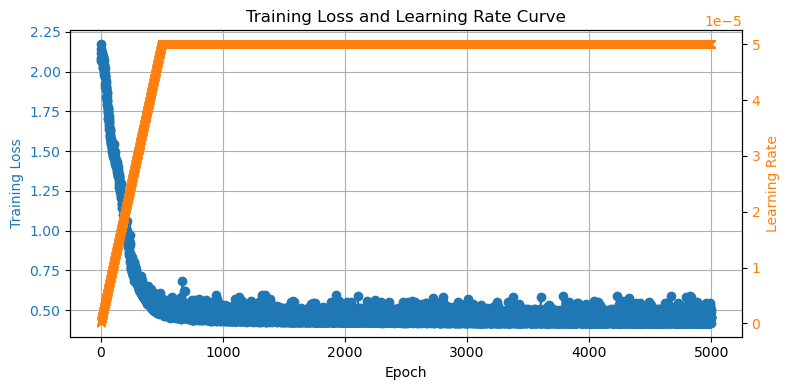

Training fold 4/precision with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 4, 'learning_rate': 5e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.0024, LR: 0.000000
Epoch 500/5000, Loss: 0.5140, LR: 0.000050
Epoch 1000/5000, Loss: 0.4813, LR: 0.000050
Epoch 1500/5000, Loss: 0.4772, LR: 0.000050
Epoch 2000/5000, Loss: 0.4847, LR: 0.000050
Epoch 2500/5000, Loss: 0.4876, LR: 0.000050
Epoch 3000/5000, Loss: 0.4782, LR: 0.000050
Epoch 3500/5000, Loss: 0.4766, LR: 0.000050
Epoch 4000/5000, Loss: 0.4773, LR: 0.000050
Epoch 4500/5000, Loss: 0.4798, LR: 0.000050
Epoch 5000/5000, Loss: 0.4801, LR: 0.000050


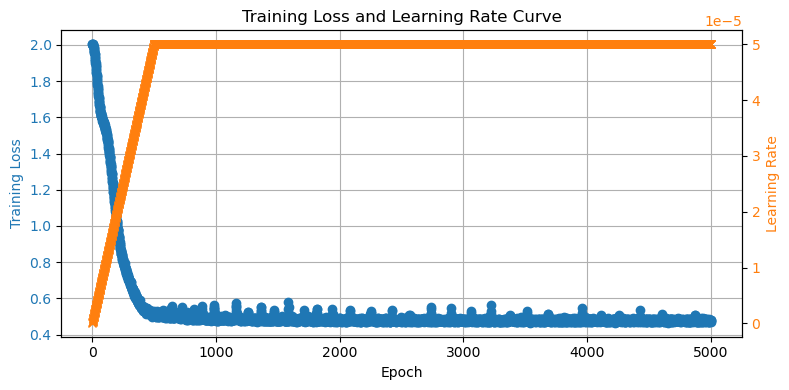

Training fold 5/precision with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 4, 'learning_rate': 5e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.1499, LR: 0.000000
Epoch 500/5000, Loss: 0.5157, LR: 0.000050
Epoch 1000/5000, Loss: 0.4928, LR: 0.000050
Epoch 1500/5000, Loss: 0.4906, LR: 0.000050
Epoch 2000/5000, Loss: 0.4884, LR: 0.000050
Epoch 2500/5000, Loss: 0.4829, LR: 0.000050
Epoch 3000/5000, Loss: 0.4827, LR: 0.000050
Epoch 3500/5000, Loss: 0.4816, LR: 0.000050
Epoch 4000/5000, Loss: 0.4817, LR: 0.000050
Epoch 4500/5000, Loss: 0.4811, LR: 0.000050
Epoch 5000/5000, Loss: 0.4822, LR: 0.000050


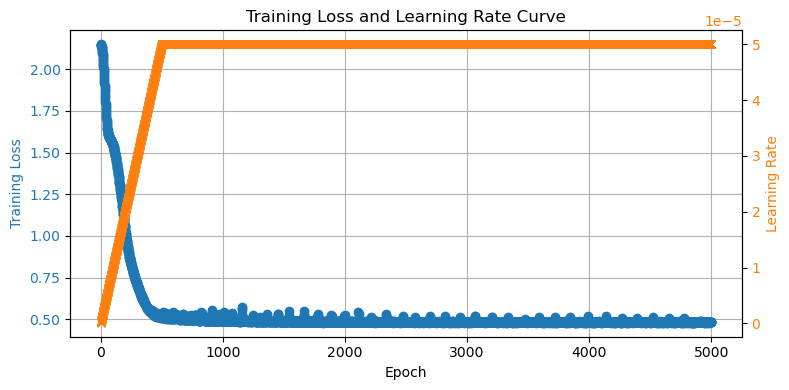

Epoch 1/5000, Loss: 2.0921, LR: 0.000000
Epoch 500/5000, Loss: 0.5453, LR: 0.000050
Epoch 1000/5000, Loss: 0.5017, LR: 0.000050
Epoch 1500/5000, Loss: 0.4981, LR: 0.000050
Epoch 2000/5000, Loss: 0.5257, LR: 0.000050
Epoch 2500/5000, Loss: 0.5098, LR: 0.000050
Epoch 3000/5000, Loss: 0.4761, LR: 0.000050
Epoch 3500/5000, Loss: 0.4936, LR: 0.000050
Epoch 4000/5000, Loss: 0.4759, LR: 0.000050
Epoch 4500/5000, Loss: 0.5007, LR: 0.000050
Epoch 5000/5000, Loss: 0.5131, LR: 0.000050


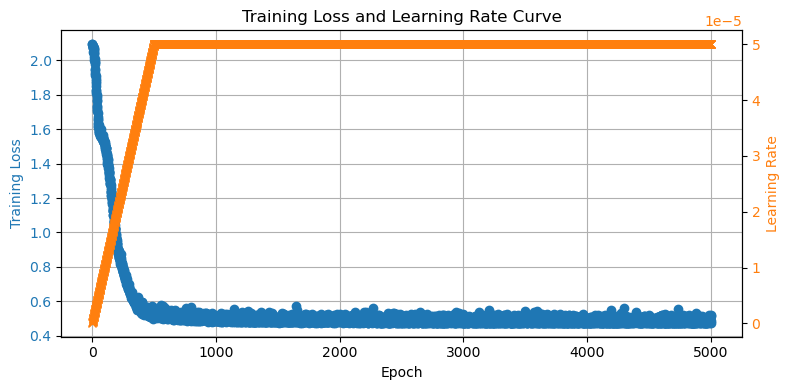

{'home_goals_train_accuracy': 0.801598440545809, 'home_goals_train_precision': 0.9444396328461442, 'home_goals_valid_accuracy': 0.27953216374269, 'home_goals_valid_precision': 0.14370022334038296, 'home_goals_test_accuracy': 0.27631578947368424, 'home_goals_test_precision': 0.14230967749418608, 'home_goals_train_lte_0_accuracy': 0.9341520467836256, 'home_goals_train_lte_0_accuracy_std': 0.007736999021539761, 'home_goals_train_lte_0_precision': 1.0, 'home_goals_train_lte_0_precision_std': 0.0, 'home_goals_train_gt_0_accuracy': 0.9341520467836256, 'home_goals_train_gt_0_accuracy_std': 0.007736999021539761, 'home_goals_train_gt_0_precision': 0.9198593658407702, 'home_goals_train_gt_0_precision_std': 0.010755488823689506, 'home_goals_train_gt_1_accuracy': 0.8680311890838206, 'home_goals_train_gt_1_accuracy_std': 0.008854924681273989, 'home_goals_train_gt_1_precision': 0.9554545454545454, 'home_goals_train_gt_1_precision_std': 0.0890909090909091, 'home_goals_train_gt_2_accuracy': 0.94505847

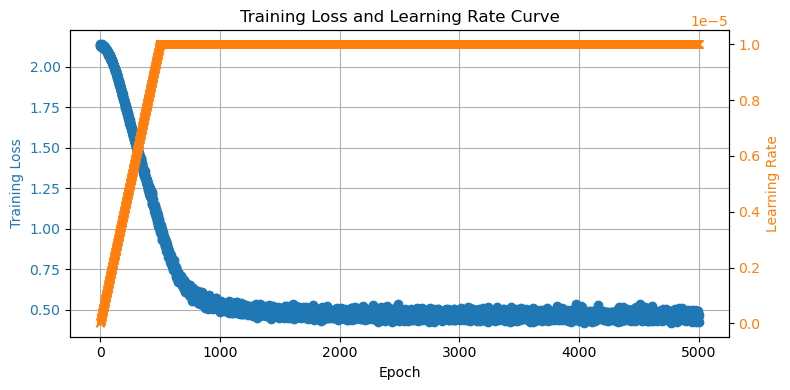

Training fold 2/precision with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 3, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 3.0589, LR: 0.000000
Epoch 500/5000, Loss: 0.7960, LR: 0.000010
Epoch 1000/5000, Loss: 0.4765, LR: 0.000010
Epoch 1500/5000, Loss: 0.4562, LR: 0.000010
Epoch 2000/5000, Loss: 0.4582, LR: 0.000010
Epoch 2500/5000, Loss: 0.4422, LR: 0.000010
Epoch 3000/5000, Loss: 0.4513, LR: 0.000010
Epoch 3500/5000, Loss: 0.4504, LR: 0.000010
Epoch 4000/5000, Loss: 0.4483, LR: 0.000010
Epoch 4500/5000, Loss: 0.4434, LR: 0.000010
Epoch 5000/5000, Loss: 0.4500, LR: 0.000010


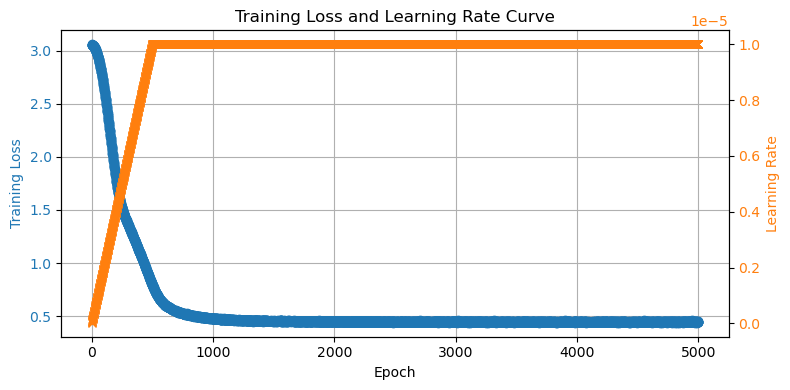

Training fold 3/precision with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 3, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.2962, LR: 0.000000
Epoch 500/5000, Loss: 0.6649, LR: 0.000010
Epoch 1000/5000, Loss: 0.4778, LR: 0.000010
Epoch 1500/5000, Loss: 0.4265, LR: 0.000010
Epoch 2000/5000, Loss: 0.4238, LR: 0.000010
Epoch 2500/5000, Loss: 0.5027, LR: 0.000010
Epoch 3000/5000, Loss: 0.4850, LR: 0.000010
Epoch 3500/5000, Loss: 0.4225, LR: 0.000010
Epoch 4000/5000, Loss: 0.4636, LR: 0.000010
Epoch 4500/5000, Loss: 0.5074, LR: 0.000010
Epoch 5000/5000, Loss: 0.4633, LR: 0.000010


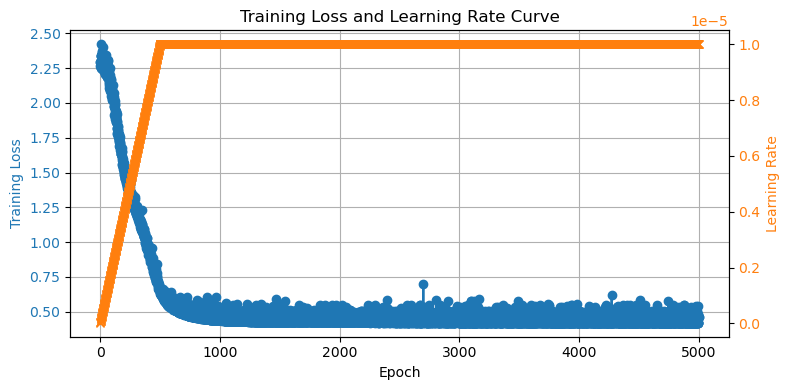

Training fold 4/precision with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 3, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.0148, LR: 0.000000
Epoch 500/5000, Loss: 0.6692, LR: 0.000010
Epoch 1000/5000, Loss: 0.4899, LR: 0.000010
Epoch 1500/5000, Loss: 0.4809, LR: 0.000010
Epoch 2000/5000, Loss: 0.4994, LR: 0.000010
Epoch 2500/5000, Loss: 0.4792, LR: 0.000010
Epoch 3000/5000, Loss: 0.4807, LR: 0.000010
Epoch 3500/5000, Loss: 0.4780, LR: 0.000010
Epoch 4000/5000, Loss: 0.4817, LR: 0.000010
Epoch 4500/5000, Loss: 0.4887, LR: 0.000010
Epoch 5000/5000, Loss: 0.4807, LR: 0.000010


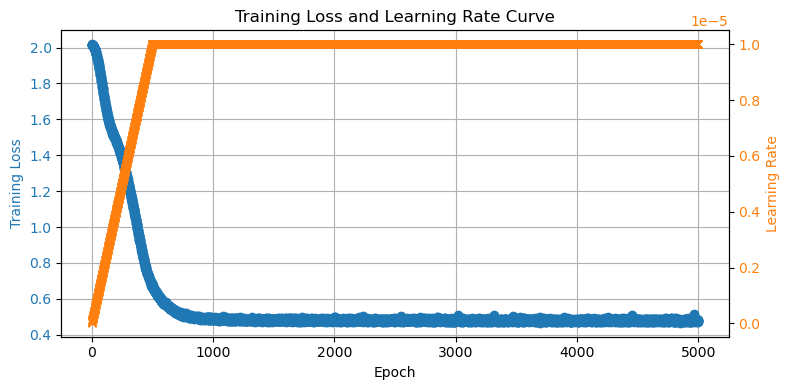

Training fold 5/precision with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 3, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.0036, LR: 0.000000
Epoch 500/5000, Loss: 0.6529, LR: 0.000010
Epoch 1000/5000, Loss: 0.4909, LR: 0.000010
Epoch 1500/5000, Loss: 0.4870, LR: 0.000010
Epoch 2000/5000, Loss: 0.4848, LR: 0.000010
Epoch 2500/5000, Loss: 0.4866, LR: 0.000010
Epoch 3000/5000, Loss: 0.4865, LR: 0.000010
Epoch 3500/5000, Loss: 0.4846, LR: 0.000010
Epoch 4000/5000, Loss: 0.4859, LR: 0.000010
Epoch 4500/5000, Loss: 0.4836, LR: 0.000010
Epoch 5000/5000, Loss: 0.4817, LR: 0.000010


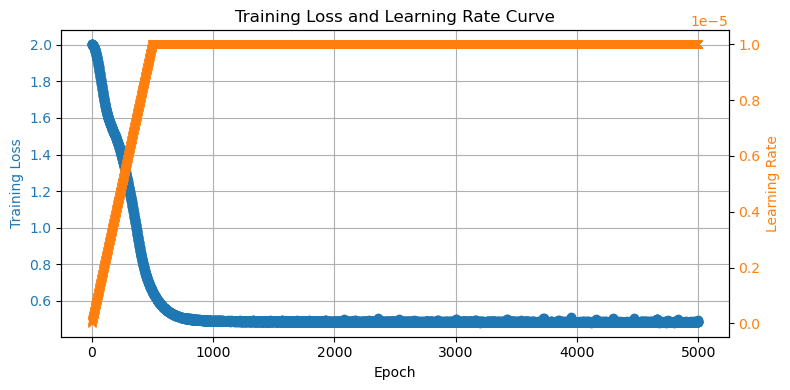

Epoch 1/5000, Loss: 2.0339, LR: 0.000000
Epoch 500/5000, Loss: 0.6186, LR: 0.000010
Epoch 1000/5000, Loss: 0.4998, LR: 0.000010
Epoch 1500/5000, Loss: 0.4970, LR: 0.000010
Epoch 2000/5000, Loss: 0.4897, LR: 0.000010
Epoch 2500/5000, Loss: 0.4873, LR: 0.000010
Epoch 3000/5000, Loss: 0.4976, LR: 0.000010
Epoch 3500/5000, Loss: 0.4777, LR: 0.000010
Epoch 4000/5000, Loss: 0.4887, LR: 0.000010
Epoch 4500/5000, Loss: 0.4999, LR: 0.000010
Epoch 5000/5000, Loss: 0.4793, LR: 0.000010


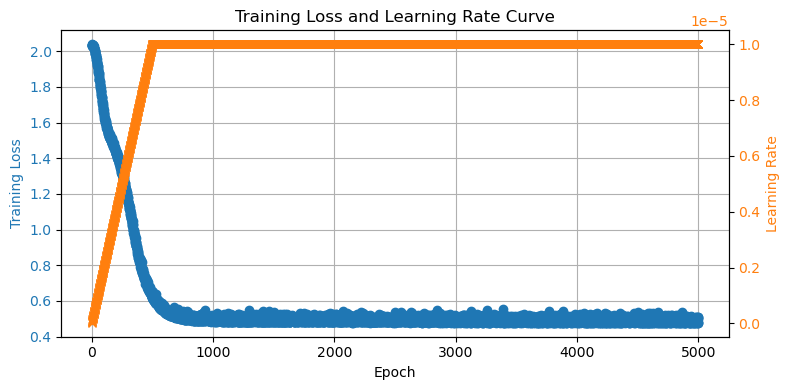

{'home_goals_train_accuracy': 0.801598440545809, 'home_goals_train_precision': 0.9444396328461442, 'home_goals_valid_accuracy': 0.2807017543859649, 'home_goals_valid_precision': 0.1379735003199934, 'home_goals_test_accuracy': 0.29385964912280704, 'home_goals_test_precision': 0.22550322061191624, 'home_goals_train_lte_0_accuracy': 0.9341520467836256, 'home_goals_train_lte_0_accuracy_std': 0.007736999021539761, 'home_goals_train_lte_0_precision': 1.0, 'home_goals_train_lte_0_precision_std': 0.0, 'home_goals_train_gt_0_accuracy': 0.9341520467836256, 'home_goals_train_gt_0_accuracy_std': 0.007736999021539761, 'home_goals_train_gt_0_precision': 0.9198593658407702, 'home_goals_train_gt_0_precision_std': 0.010755488823689506, 'home_goals_train_gt_1_accuracy': 0.8680311890838206, 'home_goals_train_gt_1_accuracy_std': 0.008854924681273989, 'home_goals_train_gt_1_precision': 0.9554545454545454, 'home_goals_train_gt_1_precision_std': 0.0890909090909091, 'home_goals_train_gt_2_accuracy': 0.9450584

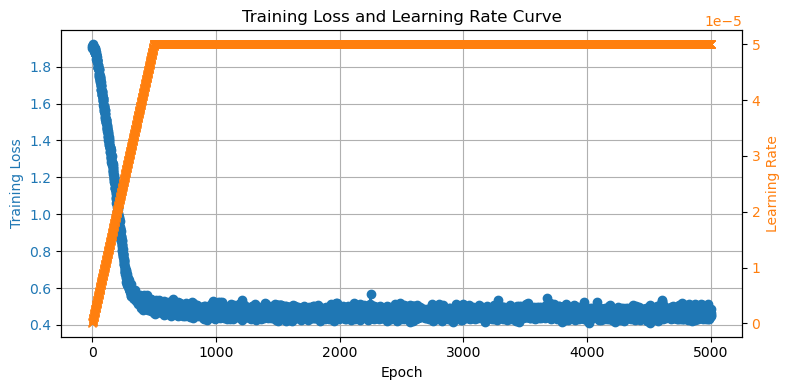

Training fold 2/precision with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 3, 'learning_rate': 5e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.2558, LR: 0.000000
Epoch 500/5000, Loss: 0.4693, LR: 0.000050
Epoch 1000/5000, Loss: 0.4461, LR: 0.000050
Epoch 1500/5000, Loss: 0.4496, LR: 0.000050
Epoch 2000/5000, Loss: 0.4431, LR: 0.000050
Epoch 2500/5000, Loss: 0.4453, LR: 0.000050
Epoch 3000/5000, Loss: 0.4435, LR: 0.000050
Epoch 3500/5000, Loss: 0.4453, LR: 0.000050
Epoch 4000/5000, Loss: 0.4437, LR: 0.000050
Epoch 4500/5000, Loss: 0.4422, LR: 0.000050
Epoch 5000/5000, Loss: 0.4479, LR: 0.000050


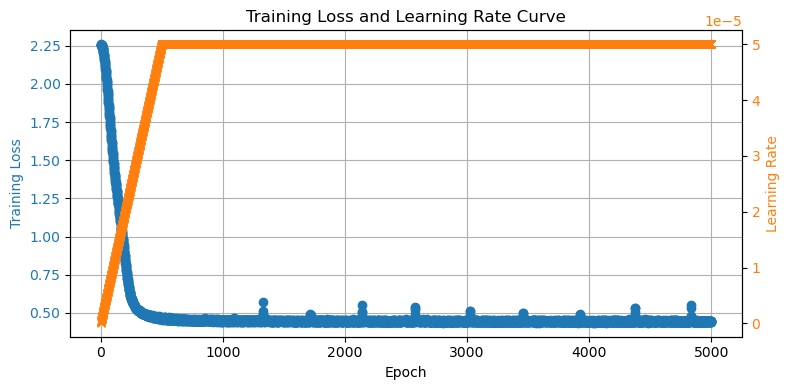

Training fold 3/precision with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 3, 'learning_rate': 5e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.2143, LR: 0.000000
Epoch 500/5000, Loss: 0.4413, LR: 0.000050
Epoch 1000/5000, Loss: 0.4698, LR: 0.000050
Epoch 1500/5000, Loss: 0.4218, LR: 0.000050
Epoch 2000/5000, Loss: 0.4236, LR: 0.000050
Epoch 2500/5000, Loss: 0.4203, LR: 0.000050
Epoch 3000/5000, Loss: 0.4608, LR: 0.000050
Epoch 3500/5000, Loss: 0.4215, LR: 0.000050
Epoch 4000/5000, Loss: 0.4603, LR: 0.000050
Epoch 4500/5000, Loss: 0.4611, LR: 0.000050
Epoch 5000/5000, Loss: 0.5058, LR: 0.000050


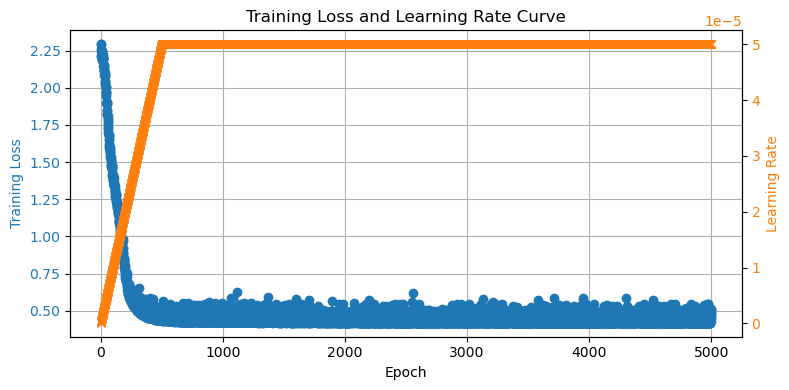

Training fold 4/precision with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 3, 'learning_rate': 5e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.1942, LR: 0.000000
Epoch 500/5000, Loss: 0.4881, LR: 0.000050
Epoch 1000/5000, Loss: 0.4731, LR: 0.000050
Epoch 1500/5000, Loss: 0.4824, LR: 0.000050
Epoch 2000/5000, Loss: 0.4834, LR: 0.000050
Epoch 2500/5000, Loss: 0.4786, LR: 0.000050
Epoch 3000/5000, Loss: 0.4736, LR: 0.000050
Epoch 3500/5000, Loss: 0.4701, LR: 0.000050
Epoch 4000/5000, Loss: 0.4723, LR: 0.000050
Epoch 4500/5000, Loss: 0.4818, LR: 0.000050
Epoch 5000/5000, Loss: 0.4770, LR: 0.000050


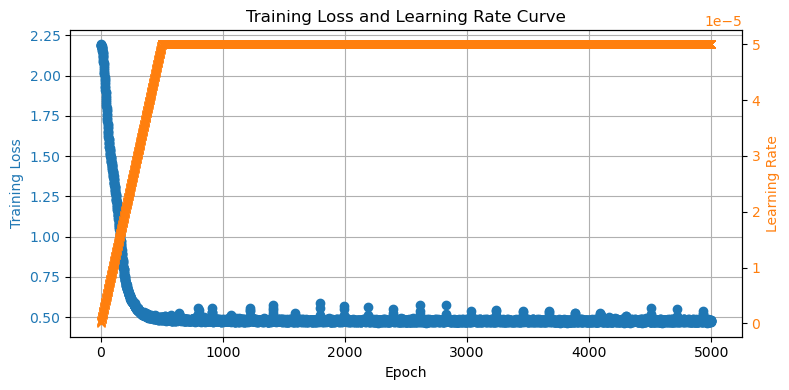

Training fold 5/precision with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 3, 'learning_rate': 5e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.1988, LR: 0.000000
Epoch 500/5000, Loss: 0.4946, LR: 0.000050
Epoch 1000/5000, Loss: 0.4878, LR: 0.000050
Epoch 1500/5000, Loss: 0.4817, LR: 0.000050
Epoch 2000/5000, Loss: 0.4811, LR: 0.000050
Epoch 2500/5000, Loss: 0.4842, LR: 0.000050
Epoch 3000/5000, Loss: 0.4856, LR: 0.000050
Epoch 3500/5000, Loss: 0.4848, LR: 0.000050
Epoch 4000/5000, Loss: 0.4813, LR: 0.000050
Epoch 4500/5000, Loss: 0.4818, LR: 0.000050
Epoch 5000/5000, Loss: 0.4827, LR: 0.000050


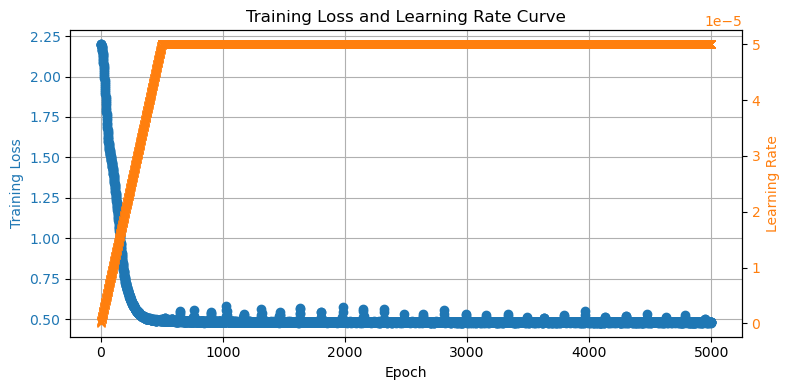

Epoch 1/5000, Loss: 2.3580, LR: 0.000000
Epoch 500/5000, Loss: 0.4894, LR: 0.000050
Epoch 1000/5000, Loss: 0.4892, LR: 0.000050
Epoch 1500/5000, Loss: 0.4937, LR: 0.000050
Epoch 2000/5000, Loss: 0.4980, LR: 0.000050
Epoch 2500/5000, Loss: 0.5449, LR: 0.000050
Epoch 3000/5000, Loss: 0.4866, LR: 0.000050
Epoch 3500/5000, Loss: 0.4948, LR: 0.000050
Epoch 4000/5000, Loss: 0.5009, LR: 0.000050
Epoch 4500/5000, Loss: 0.4825, LR: 0.000050
Epoch 5000/5000, Loss: 0.4959, LR: 0.000050


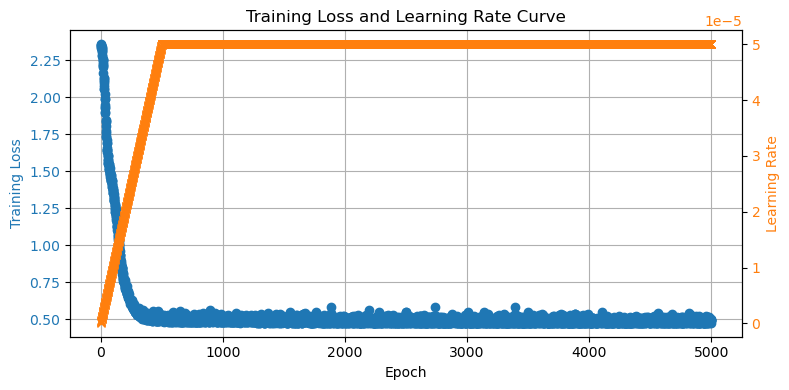

{'home_goals_train_accuracy': 0.801598440545809, 'home_goals_train_precision': 0.9444396328461442, 'home_goals_valid_accuracy': 0.28304093567251465, 'home_goals_valid_precision': 0.1650334932774308, 'home_goals_test_accuracy': 0.3157894736842105, 'home_goals_test_precision': 0.1896489773355445, 'home_goals_train_lte_0_accuracy': 0.9341520467836256, 'home_goals_train_lte_0_accuracy_std': 0.007736999021539761, 'home_goals_train_lte_0_precision': 1.0, 'home_goals_train_lte_0_precision_std': 0.0, 'home_goals_train_gt_0_accuracy': 0.9341520467836256, 'home_goals_train_gt_0_accuracy_std': 0.007736999021539761, 'home_goals_train_gt_0_precision': 0.9198593658407702, 'home_goals_train_gt_0_precision_std': 0.010755488823689506, 'home_goals_train_gt_1_accuracy': 0.8680311890838206, 'home_goals_train_gt_1_accuracy_std': 0.008854924681273989, 'home_goals_train_gt_1_precision': 0.9554545454545454, 'home_goals_train_gt_1_precision_std': 0.0890909090909091, 'home_goals_train_gt_2_accuracy': 0.94505847

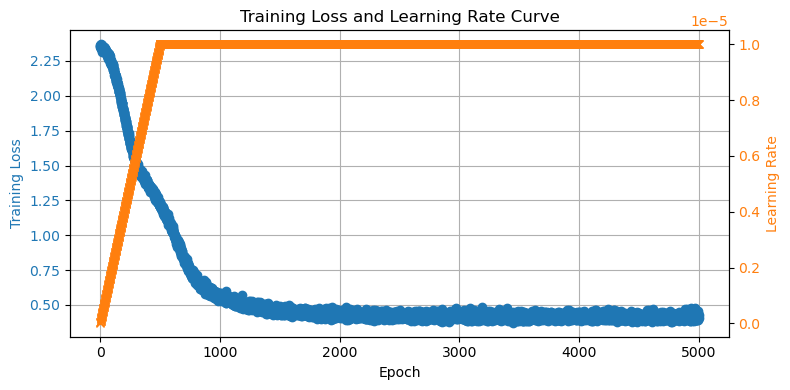

Training fold 2/5 with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 4, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.0006, LR: 0.000000
Epoch 500/5000, Loss: 1.0362, LR: 0.000010
Epoch 1000/5000, Loss: 0.5378, LR: 0.000010
Epoch 1500/5000, Loss: 0.4622, LR: 0.000010
Epoch 2000/5000, Loss: 0.4475, LR: 0.000010
Epoch 2500/5000, Loss: 0.4452, LR: 0.000010
Epoch 3000/5000, Loss: 0.4440, LR: 0.000010
Epoch 3500/5000, Loss: 0.4486, LR: 0.000010
Epoch 4000/5000, Loss: 0.4457, LR: 0.000010
Epoch 4500/5000, Loss: 0.4411, LR: 0.000010
Epoch 5000/5000, Loss: 0.4449, LR: 0.000010


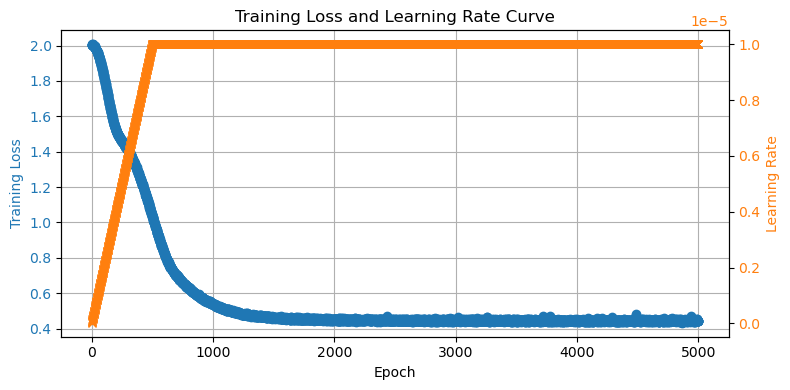

Training fold 3/5 with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 4, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.6397, LR: 0.000000
Epoch 500/5000, Loss: 0.9511, LR: 0.000010
Epoch 1000/5000, Loss: 0.5538, LR: 0.000010
Epoch 1500/5000, Loss: 0.4774, LR: 0.000010
Epoch 2000/5000, Loss: 0.4718, LR: 0.000010
Epoch 2500/5000, Loss: 0.4381, LR: 0.000010
Epoch 3000/5000, Loss: 0.4688, LR: 0.000010
Epoch 3500/5000, Loss: 0.4310, LR: 0.000010
Epoch 4000/5000, Loss: 0.4316, LR: 0.000010
Epoch 4500/5000, Loss: 0.4348, LR: 0.000010
Epoch 5000/5000, Loss: 0.4318, LR: 0.000010


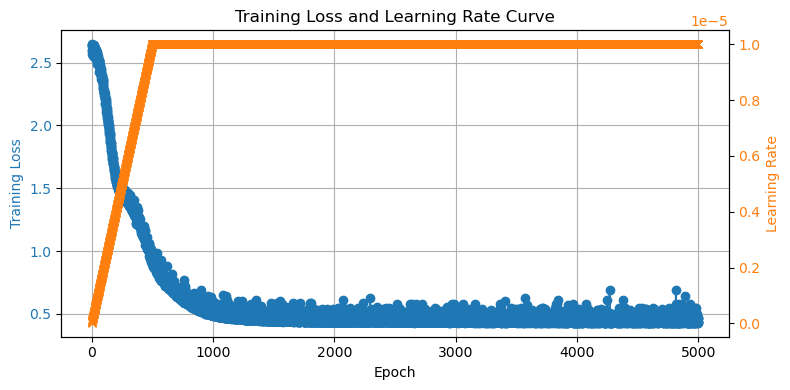

Training fold 4/5 with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 4, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.1154, LR: 0.000000
Epoch 500/5000, Loss: 0.8345, LR: 0.000010
Epoch 1000/5000, Loss: 0.4803, LR: 0.000010
Epoch 1500/5000, Loss: 0.4577, LR: 0.000010
Epoch 2000/5000, Loss: 0.4694, LR: 0.000010
Epoch 2500/5000, Loss: 0.4510, LR: 0.000010
Epoch 3000/5000, Loss: 0.4472, LR: 0.000010
Epoch 3500/5000, Loss: 0.4528, LR: 0.000010
Epoch 4000/5000, Loss: 0.4574, LR: 0.000010
Epoch 4500/5000, Loss: 0.4577, LR: 0.000010
Epoch 5000/5000, Loss: 0.4586, LR: 0.000010


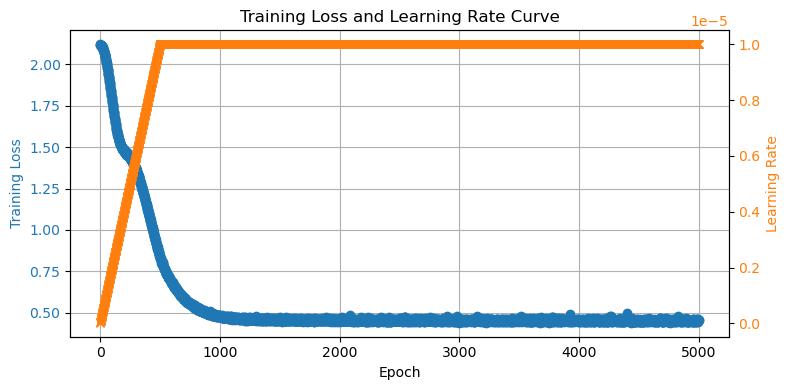

Training fold 5/5 with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 4, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.3002, LR: 0.000000
Epoch 500/5000, Loss: 0.8272, LR: 0.000010
Epoch 1000/5000, Loss: 0.4888, LR: 0.000010
Epoch 1500/5000, Loss: 0.4579, LR: 0.000010
Epoch 2000/5000, Loss: 0.4558, LR: 0.000010
Epoch 2500/5000, Loss: 0.4531, LR: 0.000010
Epoch 3000/5000, Loss: 0.4520, LR: 0.000010
Epoch 3500/5000, Loss: 0.4560, LR: 0.000010
Epoch 4000/5000, Loss: 0.4551, LR: 0.000010
Epoch 4500/5000, Loss: 0.4535, LR: 0.000010
Epoch 5000/5000, Loss: 0.4536, LR: 0.000010


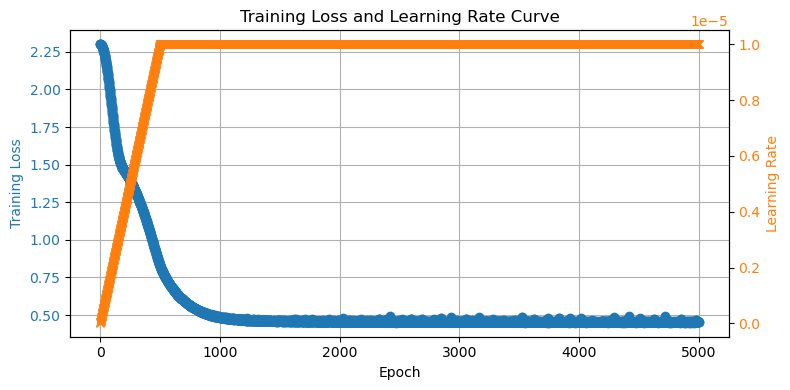

Epoch 1/5000, Loss: 2.3521, LR: 0.000000
Epoch 500/5000, Loss: 0.7872, LR: 0.000010
Epoch 1000/5000, Loss: 0.4918, LR: 0.000010
Epoch 1500/5000, Loss: 0.4587, LR: 0.000010
Epoch 2000/5000, Loss: 0.4714, LR: 0.000010
Epoch 2500/5000, Loss: 0.4582, LR: 0.000010
Epoch 3000/5000, Loss: 0.4652, LR: 0.000010
Epoch 3500/5000, Loss: 0.4708, LR: 0.000010
Epoch 4000/5000, Loss: 0.4540, LR: 0.000010
Epoch 4500/5000, Loss: 0.4668, LR: 0.000010
Epoch 5000/5000, Loss: 0.4612, LR: 0.000010


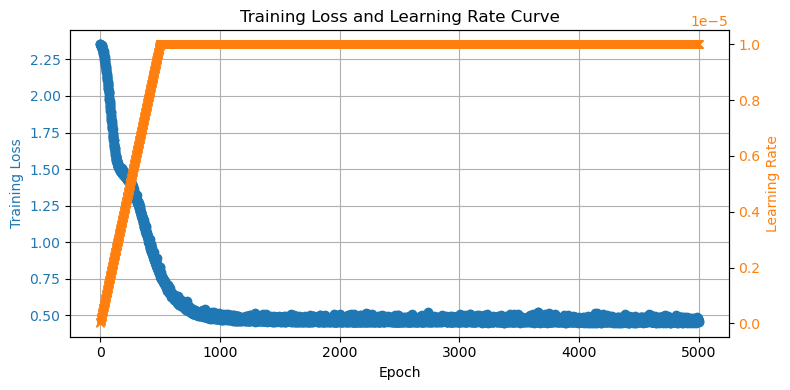

{'away_goals_train_accuracy': 0.8032748538011696, 'away_goals_train_precision': 0.8614520814728494, 'away_goals_valid_accuracy': 0.28654970760233917, 'away_goals_valid_precision': 0.15830866078522213, 'away_goals_test_accuracy': 0.25877192982456143, 'away_goals_test_precision': 0.14144282917749754, 'away_goals_train_lte_0_accuracy': 0.8032748538011696, 'away_goals_train_lte_0_accuracy_std': 0.004598737602652059, 'away_goals_train_lte_0_precision': 0.6226172022920163, 'away_goals_train_lte_0_precision_std': 0.0024505732753247124, 'away_goals_train_gt_0_accuracy': 0.8032748538011696, 'away_goals_train_gt_0_accuracy_std': 0.004598737602652059, 'away_goals_train_gt_0_precision': 1.0, 'away_goals_train_gt_0_precision_std': 0.0, 'away_goals_train_gt_1_accuracy': 0.8995321637426901, 'away_goals_train_gt_1_accuracy_std': 0.006005480665469096, 'away_goals_train_gt_1_precision': 1.0, 'away_goals_train_gt_1_precision_std': 0.0, 'away_goals_train_gt_2_accuracy': 0.9568615984405457, 'away_goals_tra

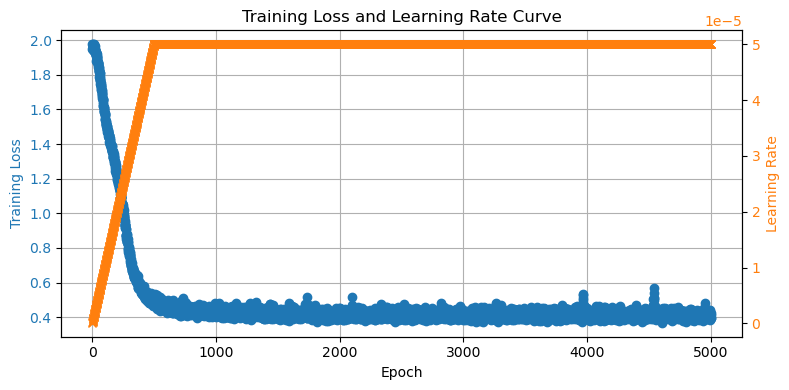

Training fold 2/precision with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 4, 'learning_rate': 5e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.3219, LR: 0.000000
Epoch 500/5000, Loss: 0.4947, LR: 0.000050
Epoch 1000/5000, Loss: 0.4631, LR: 0.000050
Epoch 1500/5000, Loss: 0.4550, LR: 0.000050
Epoch 2000/5000, Loss: 0.4643, LR: 0.000050
Epoch 2500/5000, Loss: 0.4453, LR: 0.000050
Epoch 3000/5000, Loss: 0.4456, LR: 0.000050
Epoch 3500/5000, Loss: 0.4400, LR: 0.000050
Epoch 4000/5000, Loss: 0.4366, LR: 0.000050
Epoch 4500/5000, Loss: 0.4378, LR: 0.000050
Epoch 5000/5000, Loss: 0.4473, LR: 0.000050


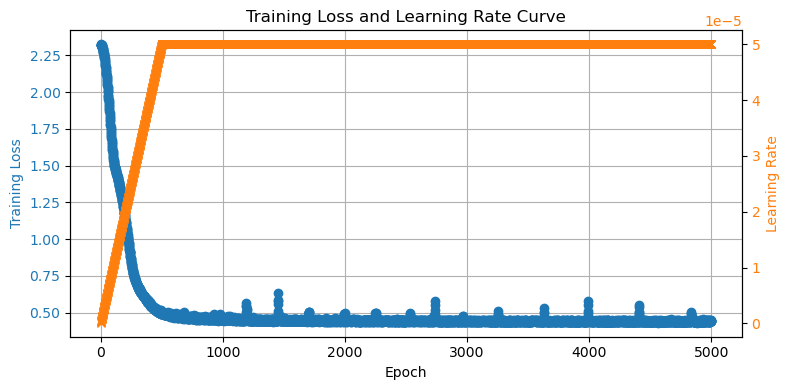

Training fold 3/precision with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 4, 'learning_rate': 5e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.1617, LR: 0.000000
Epoch 500/5000, Loss: 0.5108, LR: 0.000050
Epoch 1000/5000, Loss: 0.5589, LR: 0.000050
Epoch 1500/5000, Loss: 0.4365, LR: 0.000050
Epoch 2000/5000, Loss: 0.4887, LR: 0.000050
Epoch 2500/5000, Loss: 0.4605, LR: 0.000050
Epoch 3000/5000, Loss: 0.5138, LR: 0.000050
Epoch 3500/5000, Loss: 0.4715, LR: 0.000050
Epoch 4000/5000, Loss: 0.4644, LR: 0.000050
Epoch 4500/5000, Loss: 0.4692, LR: 0.000050
Epoch 5000/5000, Loss: 0.4599, LR: 0.000050


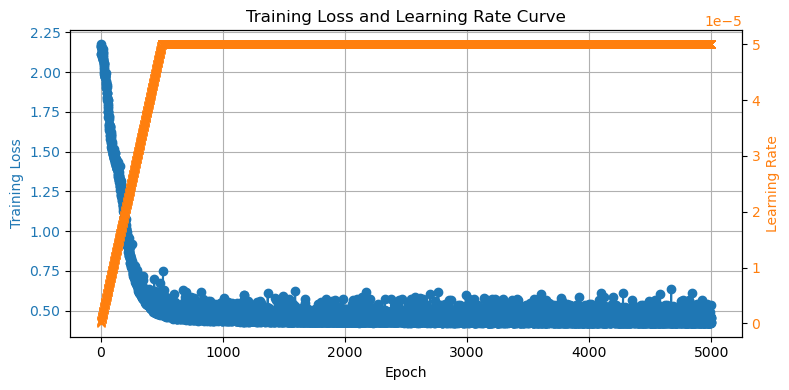

Training fold 4/precision with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 4, 'learning_rate': 5e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 1.7467, LR: 0.000000
Epoch 500/5000, Loss: 0.4755, LR: 0.000050
Epoch 1000/5000, Loss: 0.4593, LR: 0.000050
Epoch 1500/5000, Loss: 0.4480, LR: 0.000050
Epoch 2000/5000, Loss: 0.4441, LR: 0.000050
Epoch 2500/5000, Loss: 0.4459, LR: 0.000050
Epoch 3000/5000, Loss: 0.4442, LR: 0.000050
Epoch 3500/5000, Loss: 0.4421, LR: 0.000050
Epoch 4000/5000, Loss: 0.4437, LR: 0.000050
Epoch 4500/5000, Loss: 0.4475, LR: 0.000050
Epoch 5000/5000, Loss: 0.4473, LR: 0.000050


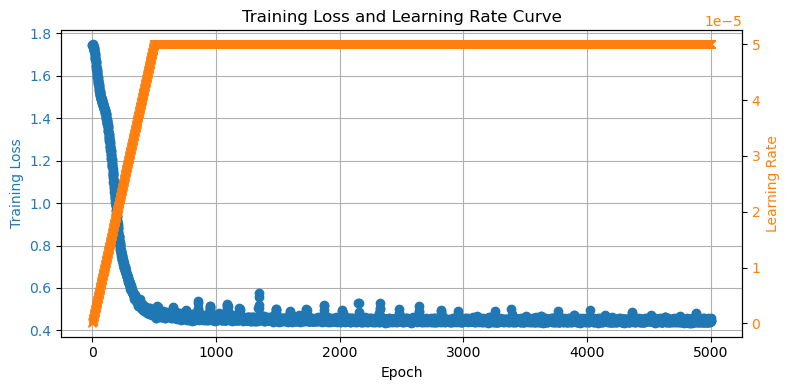

Training fold 5/precision with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 4, 'learning_rate': 5e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.5295, LR: 0.000000
Epoch 500/5000, Loss: 0.4733, LR: 0.000050
Epoch 1000/5000, Loss: 0.4586, LR: 0.000050
Epoch 1500/5000, Loss: 0.4533, LR: 0.000050
Epoch 2000/5000, Loss: 0.4516, LR: 0.000050
Epoch 2500/5000, Loss: 0.4481, LR: 0.000050
Epoch 3000/5000, Loss: 0.4487, LR: 0.000050
Epoch 3500/5000, Loss: 0.4484, LR: 0.000050
Epoch 4000/5000, Loss: 0.4461, LR: 0.000050
Epoch 4500/5000, Loss: 0.4473, LR: 0.000050
Epoch 5000/5000, Loss: 0.4466, LR: 0.000050


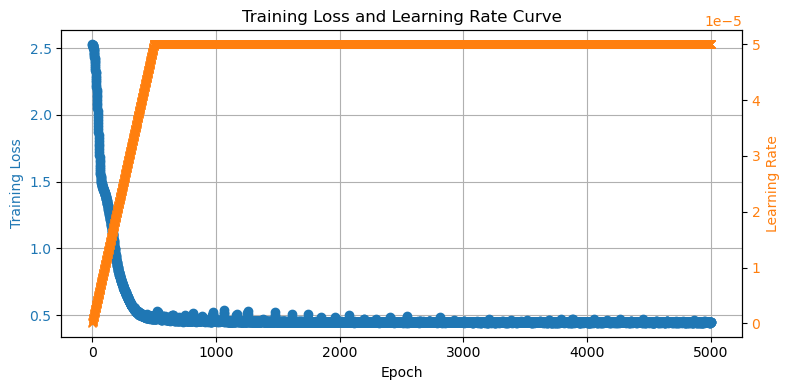

Epoch 1/5000, Loss: 2.1920, LR: 0.000000
Epoch 500/5000, Loss: 0.4801, LR: 0.000050
Epoch 1000/5000, Loss: 0.4664, LR: 0.000050
Epoch 1500/5000, Loss: 0.4547, LR: 0.000050
Epoch 2000/5000, Loss: 0.4464, LR: 0.000050
Epoch 2500/5000, Loss: 0.4617, LR: 0.000050
Epoch 3000/5000, Loss: 0.4789, LR: 0.000050
Epoch 3500/5000, Loss: 0.4455, LR: 0.000050
Epoch 4000/5000, Loss: 0.4689, LR: 0.000050
Epoch 4500/5000, Loss: 0.4528, LR: 0.000050
Epoch 5000/5000, Loss: 0.4983, LR: 0.000050


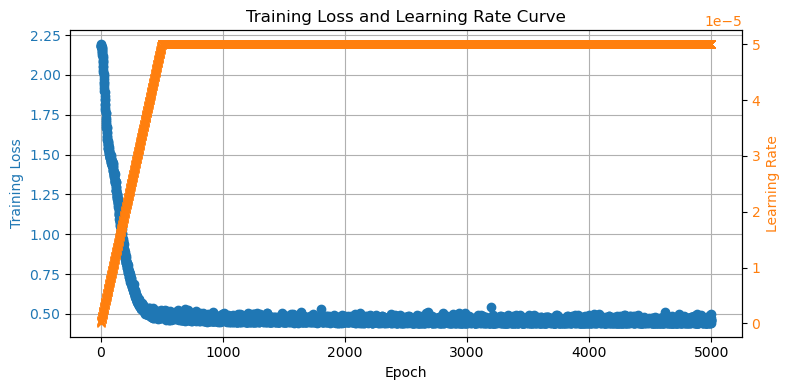

{'away_goals_train_accuracy': 0.8025730994152047, 'away_goals_train_precision': 0.8613296874554882, 'away_goals_valid_accuracy': 0.30116959064327486, 'away_goals_valid_precision': 0.12454323756628963, 'away_goals_test_accuracy': 0.3333333333333333, 'away_goals_test_precision': 0.18546824451833216, 'away_goals_train_lte_0_accuracy': 0.8235087719298246, 'away_goals_train_lte_0_accuracy_std': 0.03752253862538906, 'away_goals_train_lte_0_precision': 0.6988809385557526, 'away_goals_train_lte_0_precision_std': 0.15056661251982328, 'away_goals_train_gt_0_accuracy': 0.8235087719298246, 'away_goals_train_gt_0_accuracy_std': 0.03752253862538906, 'away_goals_train_gt_0_precision': 0.9736563209689629, 'away_goals_train_gt_0_precision_std': 0.05268735806207418, 'away_goals_train_gt_1_accuracy': 0.8995321637426901, 'away_goals_train_gt_1_accuracy_std': 0.006005480665469096, 'away_goals_train_gt_1_precision': 1.0, 'away_goals_train_gt_1_precision_std': 0.0, 'away_goals_train_gt_2_accuracy': 0.9568615

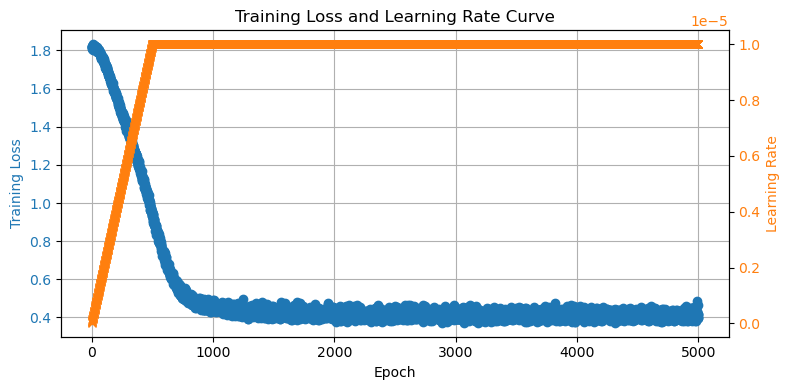

Training fold 2/precision with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 3, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 1.7842, LR: 0.000000
Epoch 500/5000, Loss: 0.7091, LR: 0.000010
Epoch 1000/5000, Loss: 0.4662, LR: 0.000010
Epoch 1500/5000, Loss: 0.4439, LR: 0.000010
Epoch 2000/5000, Loss: 0.4442, LR: 0.000010
Epoch 2500/5000, Loss: 0.4402, LR: 0.000010
Epoch 3000/5000, Loss: 0.4461, LR: 0.000010
Epoch 3500/5000, Loss: 0.4447, LR: 0.000010
Epoch 4000/5000, Loss: 0.4456, LR: 0.000010
Epoch 4500/5000, Loss: 0.4382, LR: 0.000010
Epoch 5000/5000, Loss: 0.4415, LR: 0.000010


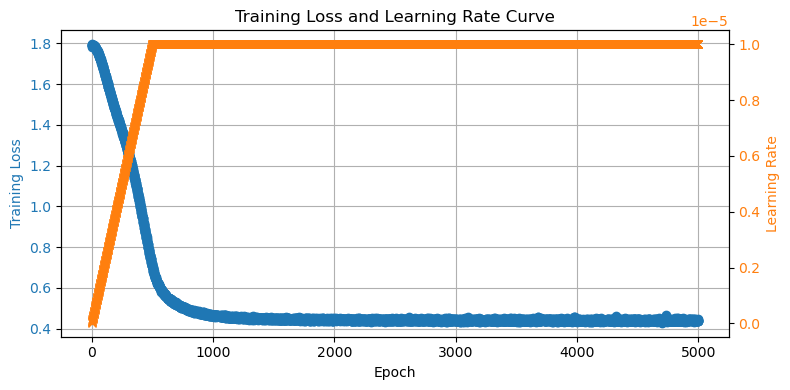

Training fold 3/precision with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 3, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.2007, LR: 0.000000
Epoch 500/5000, Loss: 0.7724, LR: 0.000010
Epoch 1000/5000, Loss: 0.4441, LR: 0.000010
Epoch 1500/5000, Loss: 0.4627, LR: 0.000010
Epoch 2000/5000, Loss: 0.4590, LR: 0.000010
Epoch 2500/5000, Loss: 0.4568, LR: 0.000010
Epoch 3000/5000, Loss: 0.4592, LR: 0.000010
Epoch 3500/5000, Loss: 0.4278, LR: 0.000010
Epoch 4000/5000, Loss: 0.4629, LR: 0.000010
Epoch 4500/5000, Loss: 0.4257, LR: 0.000010
Epoch 5000/5000, Loss: 0.4621, LR: 0.000010


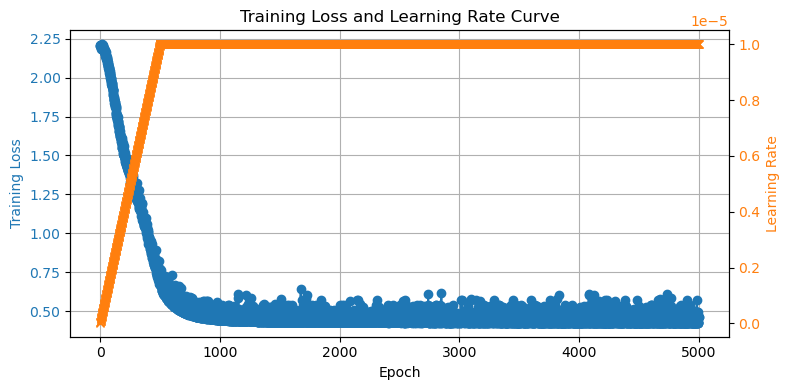

Training fold 4/precision with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 3, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.3656, LR: 0.000000
Epoch 500/5000, Loss: 0.6093, LR: 0.000010
Epoch 1000/5000, Loss: 0.4571, LR: 0.000010
Epoch 1500/5000, Loss: 0.4445, LR: 0.000010
Epoch 2000/5000, Loss: 0.4559, LR: 0.000010
Epoch 2500/5000, Loss: 0.4430, LR: 0.000010
Epoch 3000/5000, Loss: 0.4544, LR: 0.000010
Epoch 3500/5000, Loss: 0.4555, LR: 0.000010
Epoch 4000/5000, Loss: 0.4489, LR: 0.000010
Epoch 4500/5000, Loss: 0.4518, LR: 0.000010
Epoch 5000/5000, Loss: 0.4488, LR: 0.000010


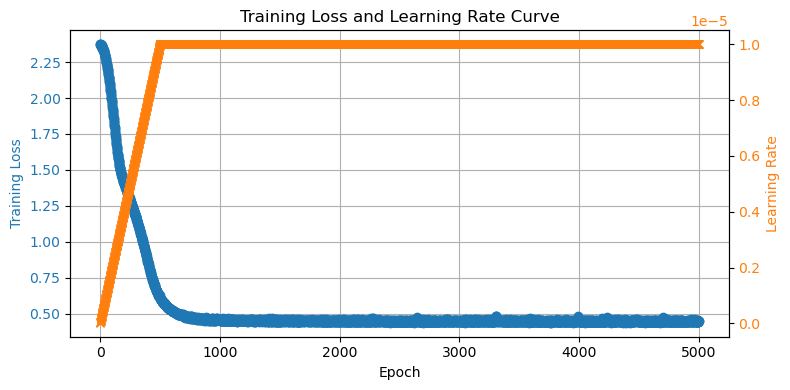

Training fold 5/precision with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 3, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.4099, LR: 0.000000
Epoch 500/5000, Loss: 0.5929, LR: 0.000010
Epoch 1000/5000, Loss: 0.4536, LR: 0.000010
Epoch 1500/5000, Loss: 0.4482, LR: 0.000010
Epoch 2000/5000, Loss: 0.4490, LR: 0.000010
Epoch 2500/5000, Loss: 0.4489, LR: 0.000010
Epoch 3000/5000, Loss: 0.4484, LR: 0.000010
Epoch 3500/5000, Loss: 0.4477, LR: 0.000010
Epoch 4000/5000, Loss: 0.4485, LR: 0.000010
Epoch 4500/5000, Loss: 0.4469, LR: 0.000010
Epoch 5000/5000, Loss: 0.4481, LR: 0.000010


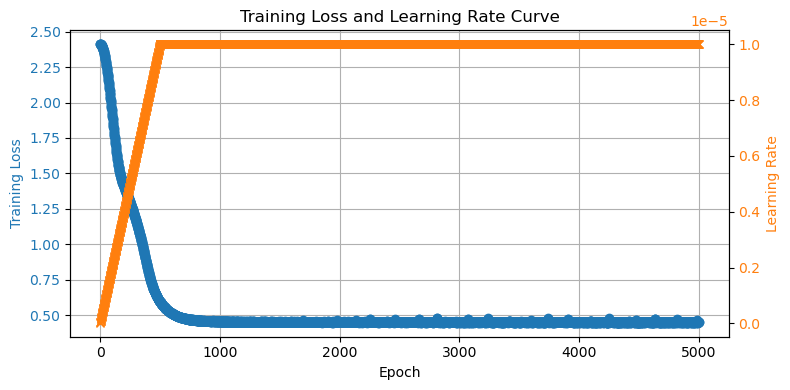

Epoch 1/5000, Loss: 2.1940, LR: 0.000000
Epoch 500/5000, Loss: 0.5794, LR: 0.000010
Epoch 1000/5000, Loss: 0.4617, LR: 0.000010
Epoch 1500/5000, Loss: 0.4647, LR: 0.000010
Epoch 2000/5000, Loss: 0.4551, LR: 0.000010
Epoch 2500/5000, Loss: 0.4486, LR: 0.000010
Epoch 3000/5000, Loss: 0.4566, LR: 0.000010
Epoch 3500/5000, Loss: 0.4589, LR: 0.000010
Epoch 4000/5000, Loss: 0.4472, LR: 0.000010
Epoch 4500/5000, Loss: 0.4532, LR: 0.000010
Epoch 5000/5000, Loss: 0.4676, LR: 0.000010


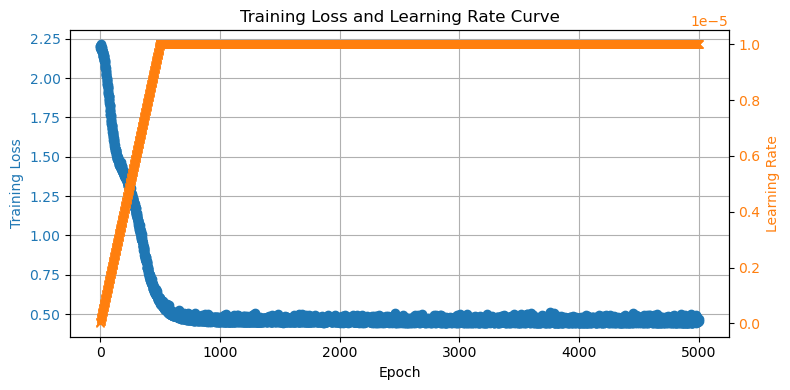

{'away_goals_train_accuracy': 0.8011111111111111, 'away_goals_train_precision': 0.8610487885790837, 'away_goals_valid_accuracy': 0.2853801169590643, 'away_goals_valid_precision': 0.13576392818430494, 'away_goals_test_accuracy': 0.35526315789473684, 'away_goals_test_precision': 0.18827257576113235, 'away_goals_train_lte_0_accuracy': 0.8416374269005849, 'away_goals_train_lte_0_accuracy_std': 0.04609344705739242, 'away_goals_train_lte_0_precision': 0.7738809385557526, 'away_goals_train_lte_0_precision_std': 0.18462980263850068, 'away_goals_train_gt_0_accuracy': 0.8416374269005849, 'away_goals_train_gt_0_accuracy_std': 0.04609344705739242, 'away_goals_train_gt_0_precision': 0.9474390925045434, 'away_goals_train_gt_0_precision_std': 0.06437401237676123, 'away_goals_train_gt_1_accuracy': 0.8995321637426901, 'away_goals_train_gt_1_accuracy_std': 0.006005480665469096, 'away_goals_train_gt_1_precision': 1.0, 'away_goals_train_gt_1_precision_std': 0.0, 'away_goals_train_gt_2_accuracy': 0.9568615

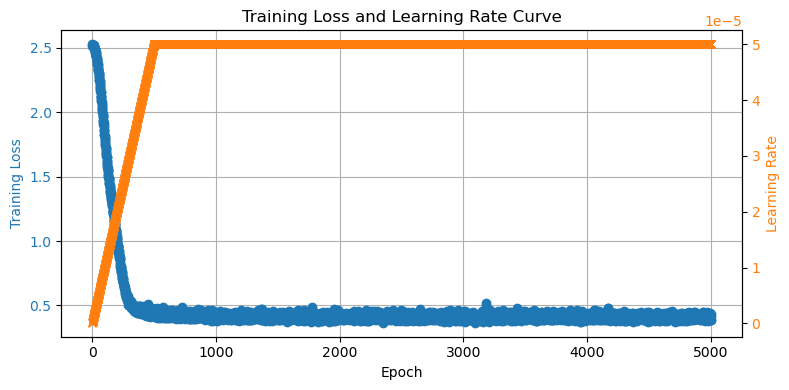

Training fold 2/precision with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 3, 'learning_rate': 5e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.0561, LR: 0.000000
Epoch 500/5000, Loss: 0.4596, LR: 0.000050
Epoch 1000/5000, Loss: 0.4451, LR: 0.000050
Epoch 1500/5000, Loss: 0.4372, LR: 0.000050
Epoch 2000/5000, Loss: 0.4387, LR: 0.000050
Epoch 2500/5000, Loss: 0.4411, LR: 0.000050
Epoch 3000/5000, Loss: 0.4453, LR: 0.000050
Epoch 3500/5000, Loss: 0.4430, LR: 0.000050
Epoch 4000/5000, Loss: 0.4406, LR: 0.000050
Epoch 4500/5000, Loss: 0.4376, LR: 0.000050
Epoch 5000/5000, Loss: 0.4418, LR: 0.000050


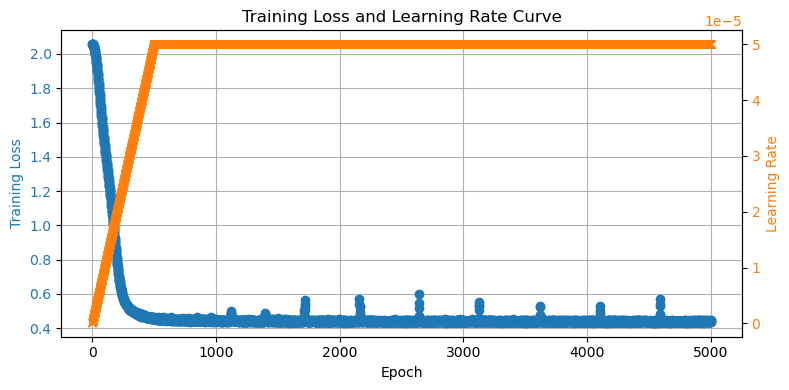

Training fold 3/precision with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 3, 'learning_rate': 5e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.4690, LR: 0.000000
Epoch 500/5000, Loss: 0.4365, LR: 0.000050
Epoch 1000/5000, Loss: 0.5020, LR: 0.000050
Epoch 1500/5000, Loss: 0.4746, LR: 0.000050
Epoch 2000/5000, Loss: 0.4575, LR: 0.000050
Epoch 2500/5000, Loss: 0.4258, LR: 0.000050
Epoch 3000/5000, Loss: 0.4560, LR: 0.000050
Epoch 3500/5000, Loss: 0.4577, LR: 0.000050
Epoch 4000/5000, Loss: 0.4254, LR: 0.000050
Epoch 4500/5000, Loss: 0.4690, LR: 0.000050
Epoch 5000/5000, Loss: 0.4242, LR: 0.000050


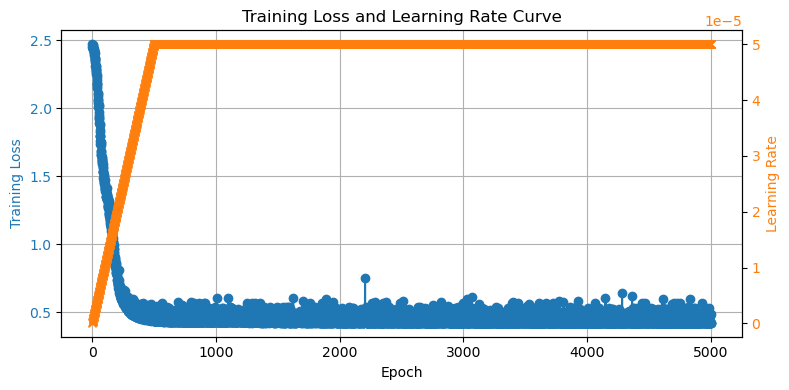

Training fold 4/precision with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 3, 'learning_rate': 5e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.3460, LR: 0.000000
Epoch 500/5000, Loss: 0.4550, LR: 0.000050
Epoch 1000/5000, Loss: 0.4476, LR: 0.000050
Epoch 1500/5000, Loss: 0.4446, LR: 0.000050
Epoch 2000/5000, Loss: 0.4483, LR: 0.000050
Epoch 2500/5000, Loss: 0.4461, LR: 0.000050
Epoch 3000/5000, Loss: 0.4439, LR: 0.000050
Epoch 3500/5000, Loss: 0.4480, LR: 0.000050
Epoch 4000/5000, Loss: 0.4484, LR: 0.000050
Epoch 4500/5000, Loss: 0.4444, LR: 0.000050
Epoch 5000/5000, Loss: 0.4500, LR: 0.000050


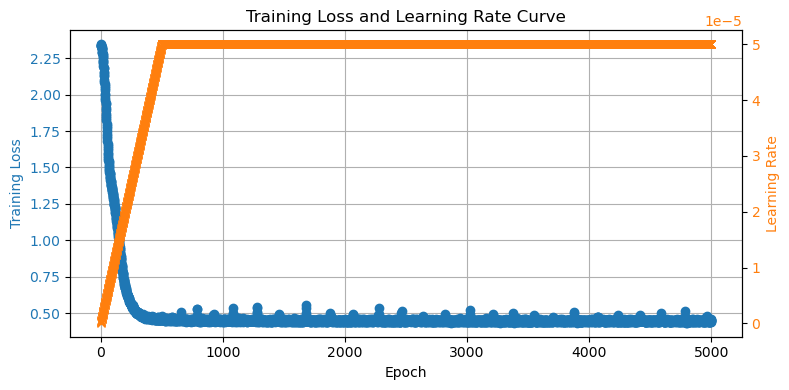

Training fold 5/precision with params: {'model_params.hidden_dim': 64, 'model_params.num_layers': 3, 'learning_rate': 5e-05, 'batch_size': 64, 'epochs': 5000}
Epoch 1/5000, Loss: 2.3593, LR: 0.000000
Epoch 500/5000, Loss: 0.4537, LR: 0.000050
Epoch 1000/5000, Loss: 0.4472, LR: 0.000050
Epoch 1500/5000, Loss: 0.4475, LR: 0.000050
Epoch 2000/5000, Loss: 0.4474, LR: 0.000050
Epoch 2500/5000, Loss: 0.4482, LR: 0.000050
Epoch 3000/5000, Loss: 0.4471, LR: 0.000050
Epoch 3500/5000, Loss: 0.4465, LR: 0.000050
Epoch 4000/5000, Loss: 0.4478, LR: 0.000050
Epoch 4500/5000, Loss: 0.4457, LR: 0.000050
Epoch 5000/5000, Loss: 0.4478, LR: 0.000050


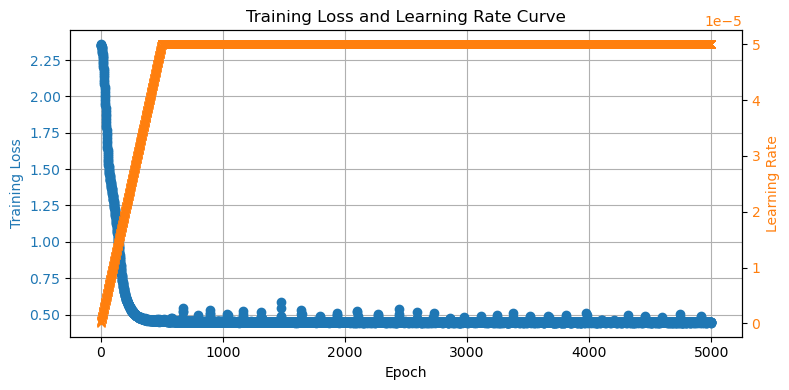

Epoch 1/5000, Loss: 2.2899, LR: 0.000000
Epoch 500/5000, Loss: 0.4941, LR: 0.000050
Epoch 1000/5000, Loss: 0.4463, LR: 0.000050
Epoch 1500/5000, Loss: 0.4536, LR: 0.000050
Epoch 2000/5000, Loss: 0.4527, LR: 0.000050
Epoch 2500/5000, Loss: 0.4611, LR: 0.000050
Epoch 3000/5000, Loss: 0.4566, LR: 0.000050
Epoch 3500/5000, Loss: 0.4720, LR: 0.000050
Epoch 4000/5000, Loss: 0.4524, LR: 0.000050
Epoch 4500/5000, Loss: 0.4600, LR: 0.000050
Epoch 5000/5000, Loss: 0.4520, LR: 0.000050


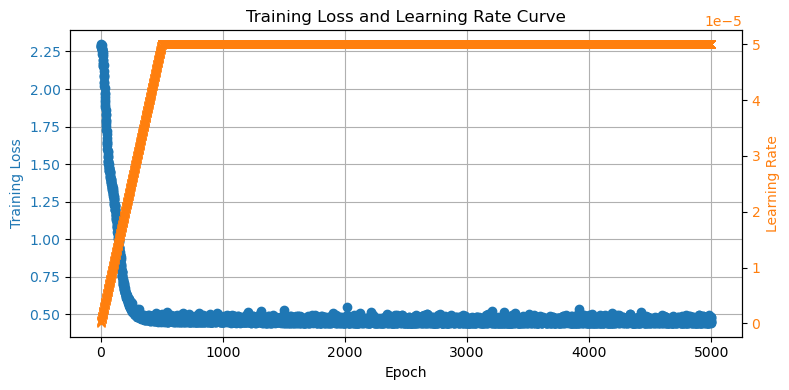

{'away_goals_train_accuracy': 0.8004970760233918, 'away_goals_train_precision': 0.8609004491653309, 'away_goals_valid_accuracy': 0.283625730994152, 'away_goals_valid_precision': 0.12518542478013195, 'away_goals_test_accuracy': 0.29385964912280704, 'away_goals_test_precision': 0.16615334207077326, 'away_goals_train_lte_0_accuracy': 0.8402631578947369, 'away_goals_train_lte_0_accuracy_std': 0.046162507002635515, 'away_goals_train_lte_0_precision': 0.7727553238389777, 'away_goals_train_lte_0_precision_std': 0.18555309731644215, 'away_goals_train_gt_0_accuracy': 0.8402631578947369, 'away_goals_train_gt_0_accuracy_std': 0.046162507002635515, 'away_goals_train_gt_0_precision': 0.9467761615261377, 'away_goals_train_gt_0_precision_std': 0.06519757112728006, 'away_goals_train_gt_1_accuracy': 0.8995321637426901, 'away_goals_train_gt_1_accuracy_std': 0.006005480665469096, 'away_goals_train_gt_1_precision': 1.0, 'away_goals_train_gt_1_precision_std': 0.0, 'away_goals_train_gt_2_accuracy': 0.956861

In [9]:
run_multiclass_distribution_experiment_seq(
    feature_df=feature_df,
    target_df=target_df,
    target_ranges=TRAINGING_CONFIG['target_ranges'],
    model_wrapper_class=lambda **params: TorchSequenceWrapper(
        model_class=LSTMClassifier,
        model_params={k.replace('model_params.', ''): v for k, v in params.items() if k.startswith('model_params.')},
        learning_rate=params.get('learning_rate', 0.001),
        batch_size=params.get('batch_size', 64),
        epochs=params.get('epochs', 20)
    ),
    model_param_grid=param_grid,
    test_size=TRAINGING_CONFIG['test_size'],
    k=5,
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    uri=f'{REPO_PATH}/mlflow',
    model_name='LSTMClassifier',
    key_columns=TRAINGING_CONFIG['key_columns'],
    sequence_length=5
)

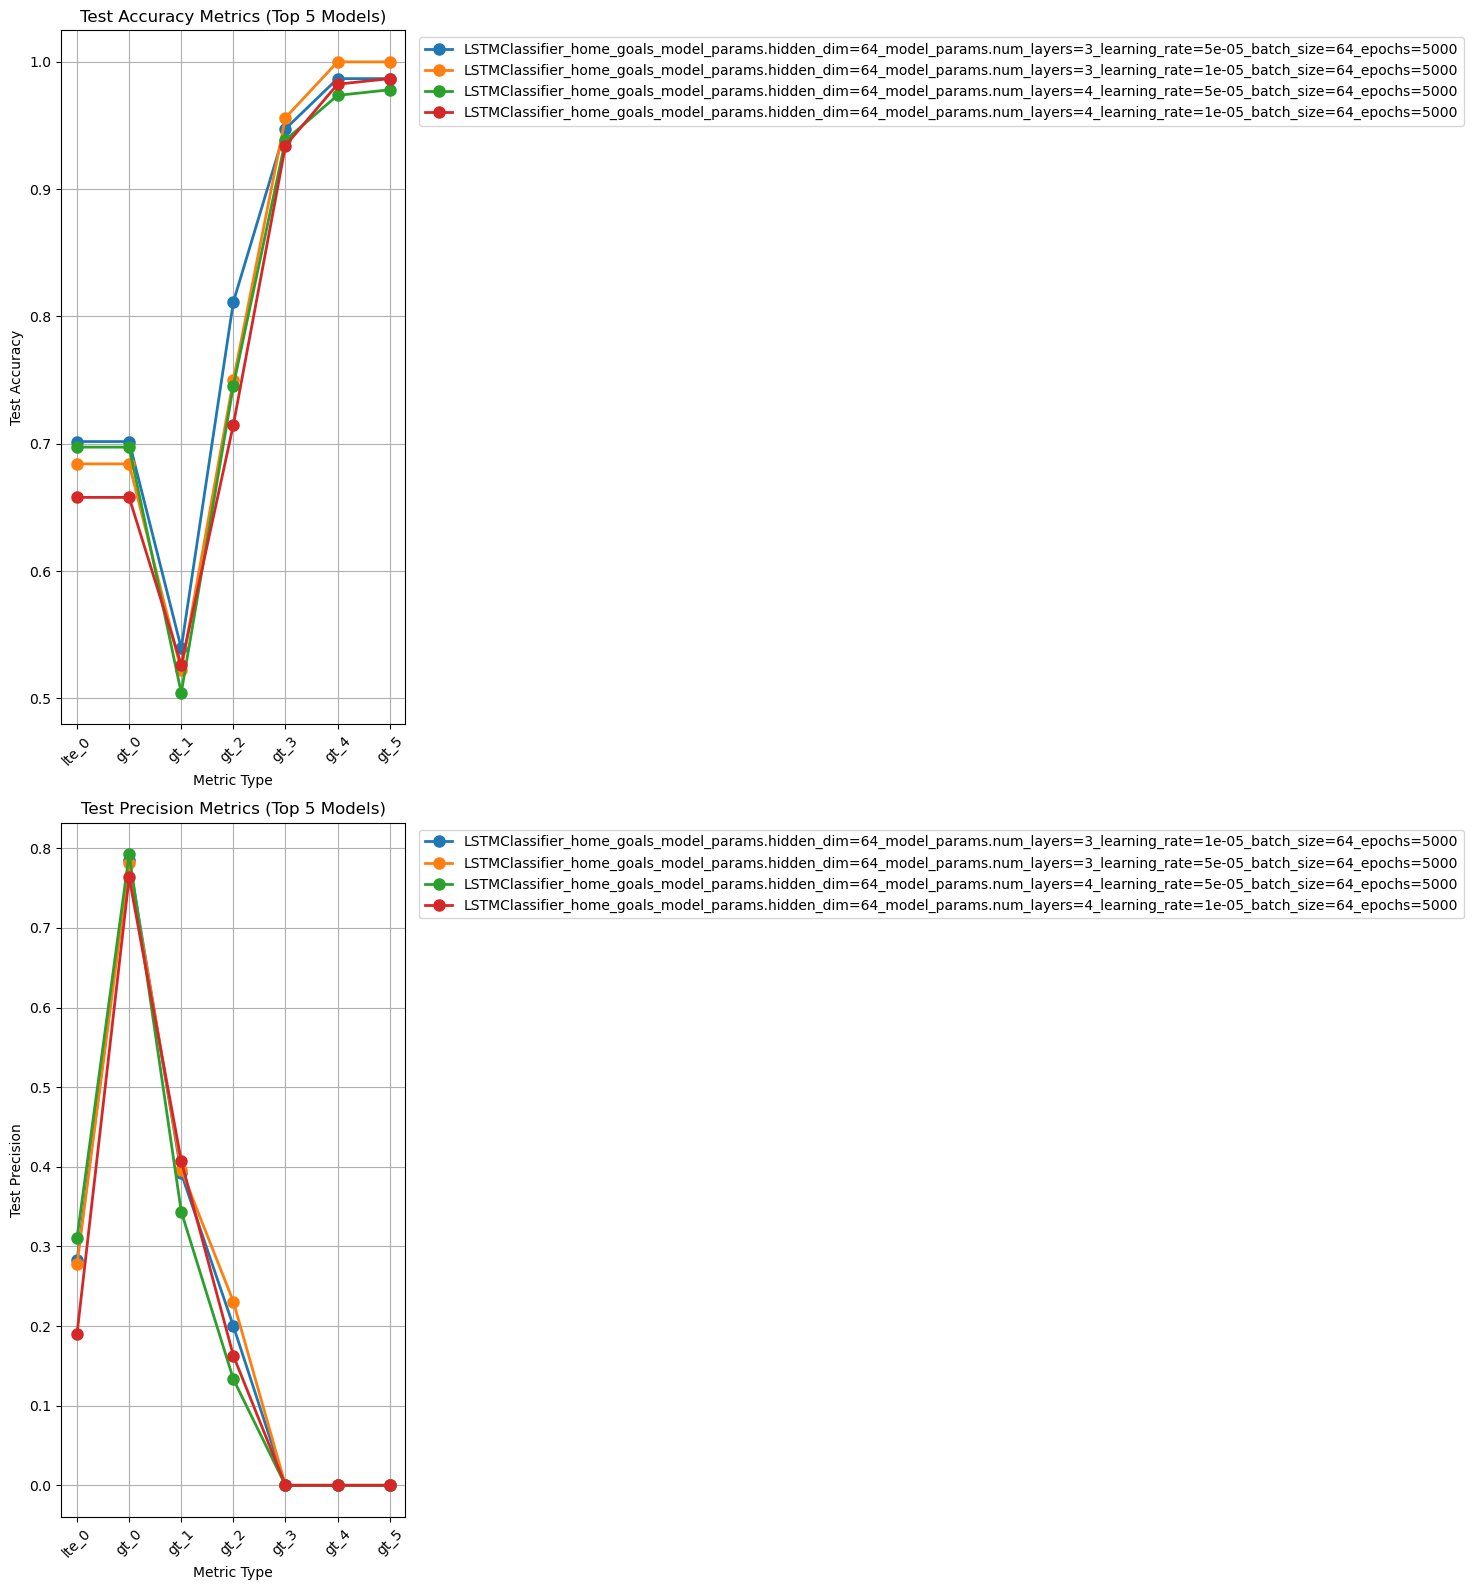

In [10]:
plot_metrics_for_target_and_model(
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    target_col="home_goals",
    model_name="LSTMClassifier",
    tracking_uri=f"{REPO_PATH}/mlflow"
)